In [21]:
import numpy as np
import pandas as pd
 
# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
 
# Prétraitement
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
 
# Prétraitement
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
 
# Modèles de Machine Learning
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
 
# Évaluation des modèles
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    mean_squared_error,
    r2_score
)

### 1- Echantillon de 10 lignes

In [22]:
df = pd.read_csv('credit_risk_dataset.csv')
pd.set_option('display.expand_frame_repr', False)
    
print(df.head(10))

   person_age  person_income person_home_ownership  person_emp_length loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  loan_percent_income cb_person_default_on_file  cb_person_cred_hist_length
0          22          59000                  RENT              123.0    PERSONAL          D      35000          16.02            1                 0.59                         Y                           3
1          21           9600                   OWN                5.0   EDUCATION          B       1000          11.14            0                 0.10                         N                           2
2          25           9600              MORTGAGE                1.0     MEDICAL          C       5500          12.87            1                 0.57                         N                           3
3          23          65500                  RENT                4.0     MEDICAL          C      35000          15.23            1                 0.53                    

### 2- Analyse statistique

In [23]:
print("\n=== Nombre de personne ayant un prêt ===")
print(f"Nombre: {df['loan_status'].mean():.2%}")

print("\n=== Répartition des types d'accession à la propriété ===")
print(df.groupby(['person_home_ownership', 'loan_status']).size().unstack(fill_value=0))

print("\n=== Répartition du grade de prêt ===")
print(df.groupby('loan_grade')['loan_status'].agg(['mean', 'count']).rename(columns={'mean': 'taux_defaut'}))

print("\n=== Répartition des intentions de prêt ===")
print(df.groupby('loan_intent')['loan_status'].agg(['mean', 'count']).rename(columns={'mean': 'taux_defaut'}))

print("\n=== Statistiques d'âge selon prêt ou non ===")
print(df.groupby('loan_status')['person_age'].agg(['mean', 'min', 'max', 'median']))

print("\n=== Statistiques de revenu ===")
print(df['person_income'].agg(['min', 'max', 'mean', 'median']))

print("\n=== Statistiques du montant de prêt ===")
print(df['loan_amnt'].agg(['min', 'max', 'mean', 'median']))

print("\n=== Statistiques du taux d'intérêt ===")
print(df['loan_int_rate'].agg(['min', 'max', 'mean', 'median']))

print("\n=== Prêt antécédent ===")
print(df['cb_person_default_on_file'].value_counts())


=== Nombre de personne ayant un prêt ===
Nombre: 21.82%

=== Répartition des types d'accession à la propriété ===
loan_status                0     1
person_home_ownership             
MORTGAGE               11754  1690
OTHER                     74    33
OWN                     2391   193
RENT                   11254  5192

=== Répartition du grade de prêt ===
            taux_defaut  count
loan_grade                    
A              0.099564  10777
B              0.162760  10451
C              0.207340   6458
D              0.590458   3626
E              0.644191    964
F              0.705394    241
G              0.984375     64

=== Répartition des intentions de prêt ===
                   taux_defaut  count
loan_intent                          
DEBTCONSOLIDATION     0.285879   5212
EDUCATION             0.172168   6453
HOMEIMPROVEMENT       0.261026   3605
MEDICAL               0.267007   6071
PERSONAL              0.198877   5521
VENTURE               0.148103   5719

=== Stati

### 3 - Cleaning

In [24]:
# Détecter les valeurs manquantes
print("=== Valeurs manquantes ===")
print(df.isnull().sum())
print(f"\nNombre total de valeurs manquantes: {df.isnull().sum().sum()}")

# Détecter les lignes en double
print("\n=== Lignes en double ===")
duplicates = df.duplicated().sum()
print(f"Nombre de lignes en double: {duplicates}")

# Supprimer les lignes en double si nécessaire
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"Lignes en double supprimées. Nouvelles dimensions: {df.shape}")

# Détecter les valeurs aberrantes (outliers)
print("\n=== Détection des valeurs aberrantes ===")
print(f"Âge maximum: {df['person_age'].max()}")
print(f"Âge minimum: {df['person_age'].min()}")
print(f"Revenu maximum: {df['person_income'].max()}")
print(f"Durée d'emploi maximum: {df['person_emp_length'].max()}")

print(f"\nDimensions finales du dataset: {df.shape}")

=== Valeurs manquantes ===
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

Nombre total de valeurs manquantes: 4011

=== Lignes en double ===
Nombre de lignes en double: 165
Lignes en double supprimées. Nouvelles dimensions: (32416, 12)

=== Détection des valeurs aberrantes ===
Âge maximum: 144
Âge minimum: 20
Revenu maximum: 6000000
Durée d'emploi maximum: 123.0

Dimensions finales du dataset: (32416, 12)


### 4 - Outliers et valeurs aberrantes

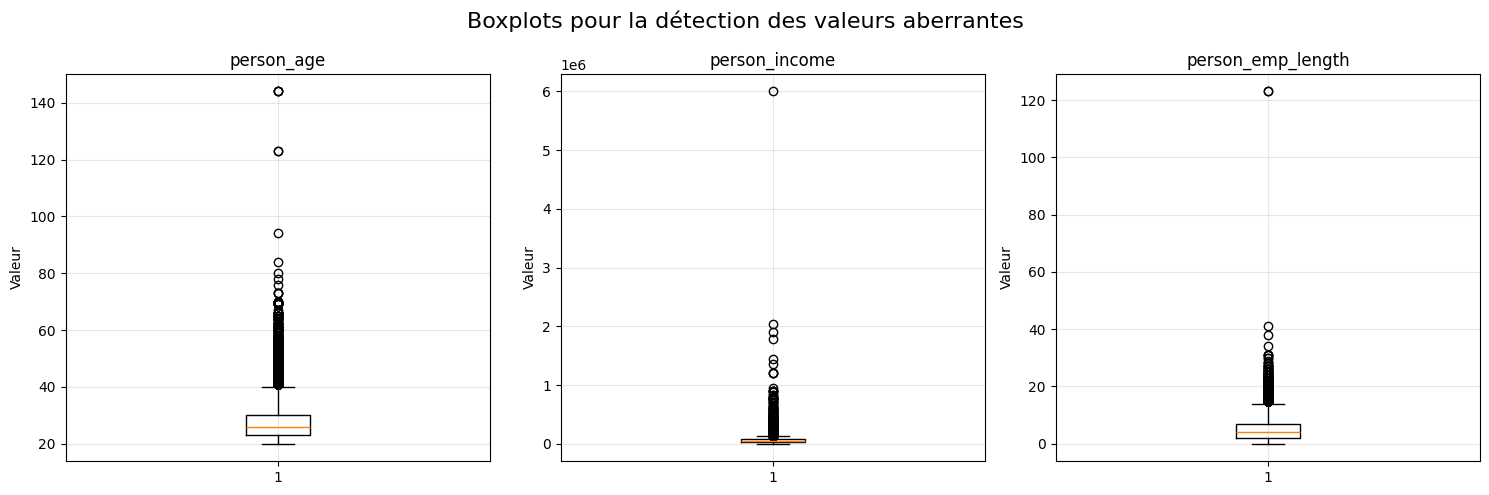

In [25]:
# Créer des boxplots pour détecter les valeurs aberrantes
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Boxplots pour la détection des valeurs aberrantes', fontsize=16)

# Liste des colonnes numériques à visualiser
numeric_columns = ['person_age', 'person_income', 'person_emp_length']

# Créer un boxplot pour chaque colonne
for idx, col in enumerate(numeric_columns):
    axes[idx].boxplot(df[col].dropna())
    axes[idx].set_title(col)
    axes[idx].set_ylabel('Valeur')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

On remarque grâce à cette analyse des valeurs abérrante qu'il y a 2 personnes de plus de 120 ans, ce qui est peut problable... Une unique personne gagne 6M par ans, ce qui fait d'elle un outlier. Et une personne a été enployée pendant 123 ans, ce qui est impossible.

### 5 - Typage et remplissage des données manquantes

In [26]:
# Convertir les colonnes au bon type de données
df['person_age'] = df['person_age'].astype(int)
df['person_income'] = df['person_income'].astype(int)
df['person_home_ownership'] = df['person_home_ownership'].astype(str)
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median()).astype(float) # Car il y a des valeurs manquantes pour cette colonne
df['loan_intent'] = df['loan_intent'].astype(str)
df['loan_grade'] = df['loan_grade'].astype(str)
df['loan_amnt'] = df['loan_amnt'].astype(int)
df['loan_int_rate'] = df['loan_int_rate'].astype(float)
df['loan_status'] = df['loan_status'].astype(bool)
df['loan_percent_income'] = df['loan_percent_income'].astype(float)
df['cb_person_default_on_file'] = df['cb_person_default_on_file'].astype(bool)
df['cb_person_cred_hist_length'] = df['cb_person_cred_hist_length'].astype(int)

print("\n=== Types de données après conversion ===")
print(df.dtypes)
print("\n=== Aperçu des données ===")
print(df.head())


=== Types de données après conversion ===
person_age                      int64
person_income                   int64
person_home_ownership          object
person_emp_length             float64
loan_intent                    object
loan_grade                     object
loan_amnt                       int64
loan_int_rate                 float64
loan_status                      bool
loan_percent_income           float64
cb_person_default_on_file        bool
cb_person_cred_hist_length      int64
dtype: object

=== Aperçu des données ===
   person_age  person_income person_home_ownership  person_emp_length loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  loan_percent_income  cb_person_default_on_file  cb_person_cred_hist_length
0          22          59000                  RENT              123.0    PERSONAL          D      35000          16.02         True                 0.59                       True                           3
1          21           9600               

### 6 - Suppression valeurs aberrantes

In [27]:
# Supprimer les personnes avec un âge > 100 ans
df = df[df['person_age'] <= 100]

# Supprimer les personnes avec une durée d'emploi > 100 ans
df = df[df['person_emp_length'] <= 100]

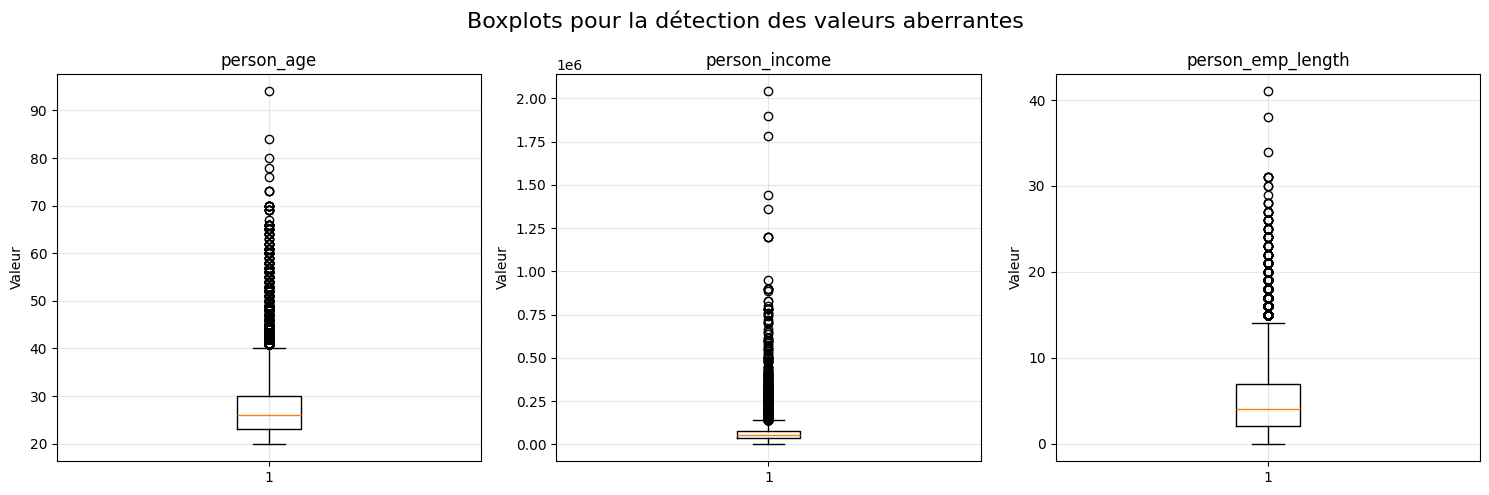

In [28]:
# Créer des boxplots après suppression des valeurs aberrantes (âge et durée d'emploi)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Boxplots pour la détection des valeurs aberrantes', fontsize=16)

# Liste des colonnes numériques à visualiser
numeric_columns = ['person_age', 'person_income', 'person_emp_length']

# Créer un boxplot pour chaque colonne
for idx, col in enumerate(numeric_columns):
    axes[idx].boxplot(df[col].dropna())
    axes[idx].set_title(col)
    axes[idx].set_ylabel('Valeur')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

L'une des personnes qui avait plus de 100 ans, avait un income de 6M, c'est pour cela qu'il n'apparait plus.

### 7 - Matrice de corrélation

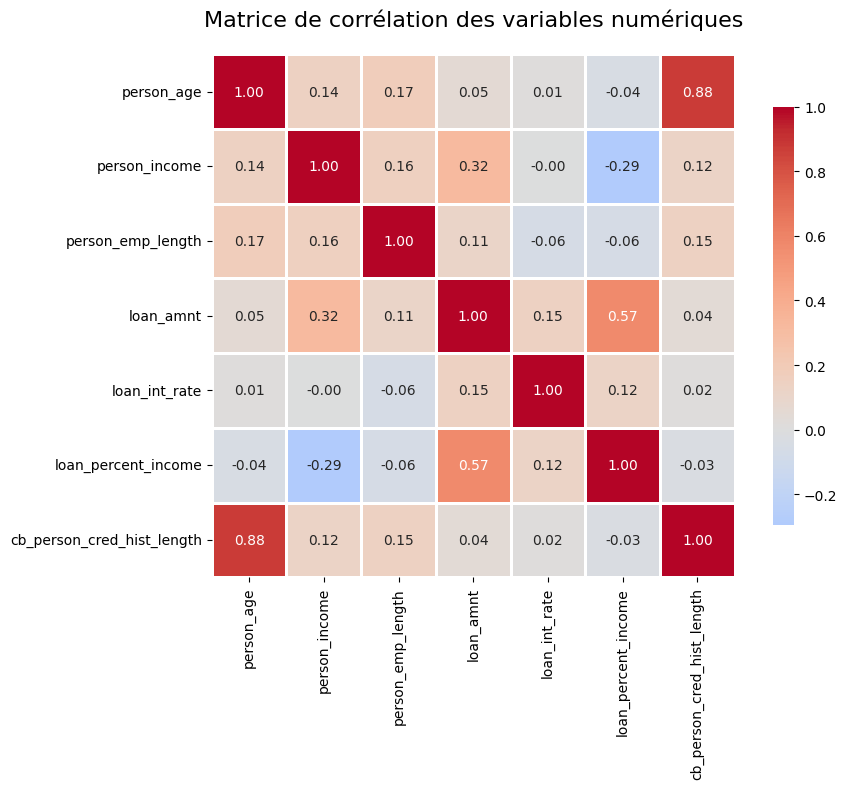


=== Matrice de corrélation ===
                            person_age  person_income  person_emp_length  loan_amnt  loan_int_rate  loan_percent_income  cb_person_cred_hist_length
person_age                    1.000000       0.140487           0.170606   0.051646       0.011129            -0.041468                    0.878240
person_income                 0.140487       1.000000           0.155094   0.316732      -0.001019            -0.294766                    0.122654
person_emp_length             0.170606       0.155094           1.000000   0.111896      -0.055771            -0.058419                    0.147920
loan_amnt                     0.051646       0.316732           0.111896   1.000000       0.146926             0.572632                    0.042139
loan_int_rate                 0.011129      -0.001019          -0.055771   0.146926       1.000000             0.120111                    0.015855
loan_percent_income          -0.041468      -0.294766          -0.058419   0.572

In [29]:
# Créer la matrice de corrélation pour les colonnes numériques uniquement
correlation_matrix = df.select_dtypes(include=[np.number]).corr()

# Afficher la matrice de corrélation
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matrice de corrélation des variables numériques', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

# Afficher également la matrice sous forme de DataFrame
print("\n=== Matrice de corrélation ===")
print(correlation_matrix)

### 8 - Skewnees

In [36]:
from scipy.stats import skew

skewness_values = {}
for col in numeric_cols:
    skew_value = skew(df[col].dropna())
    skewness_values[col] = skew_value

skewness_df = pd.DataFrame.from_dict(skewness_values, orient='index', columns=['Skewness'])
skewness_df = skewness_df.sort_values('Skewness', ascending=False)
print("\n=== Résumé du Skewness (trié par valeur) ===")
print(skewness_df)


=== Résumé du Skewness (trié par valeur) ===
                            Skewness
person_income               9.777422
person_age                  1.942269
cb_person_cred_hist_length  1.657914
person_emp_length           1.280985
loan_amnt                   1.191434
loan_percent_income         1.063234
loan_int_rate               0.207122


### 9 - Distribution normale

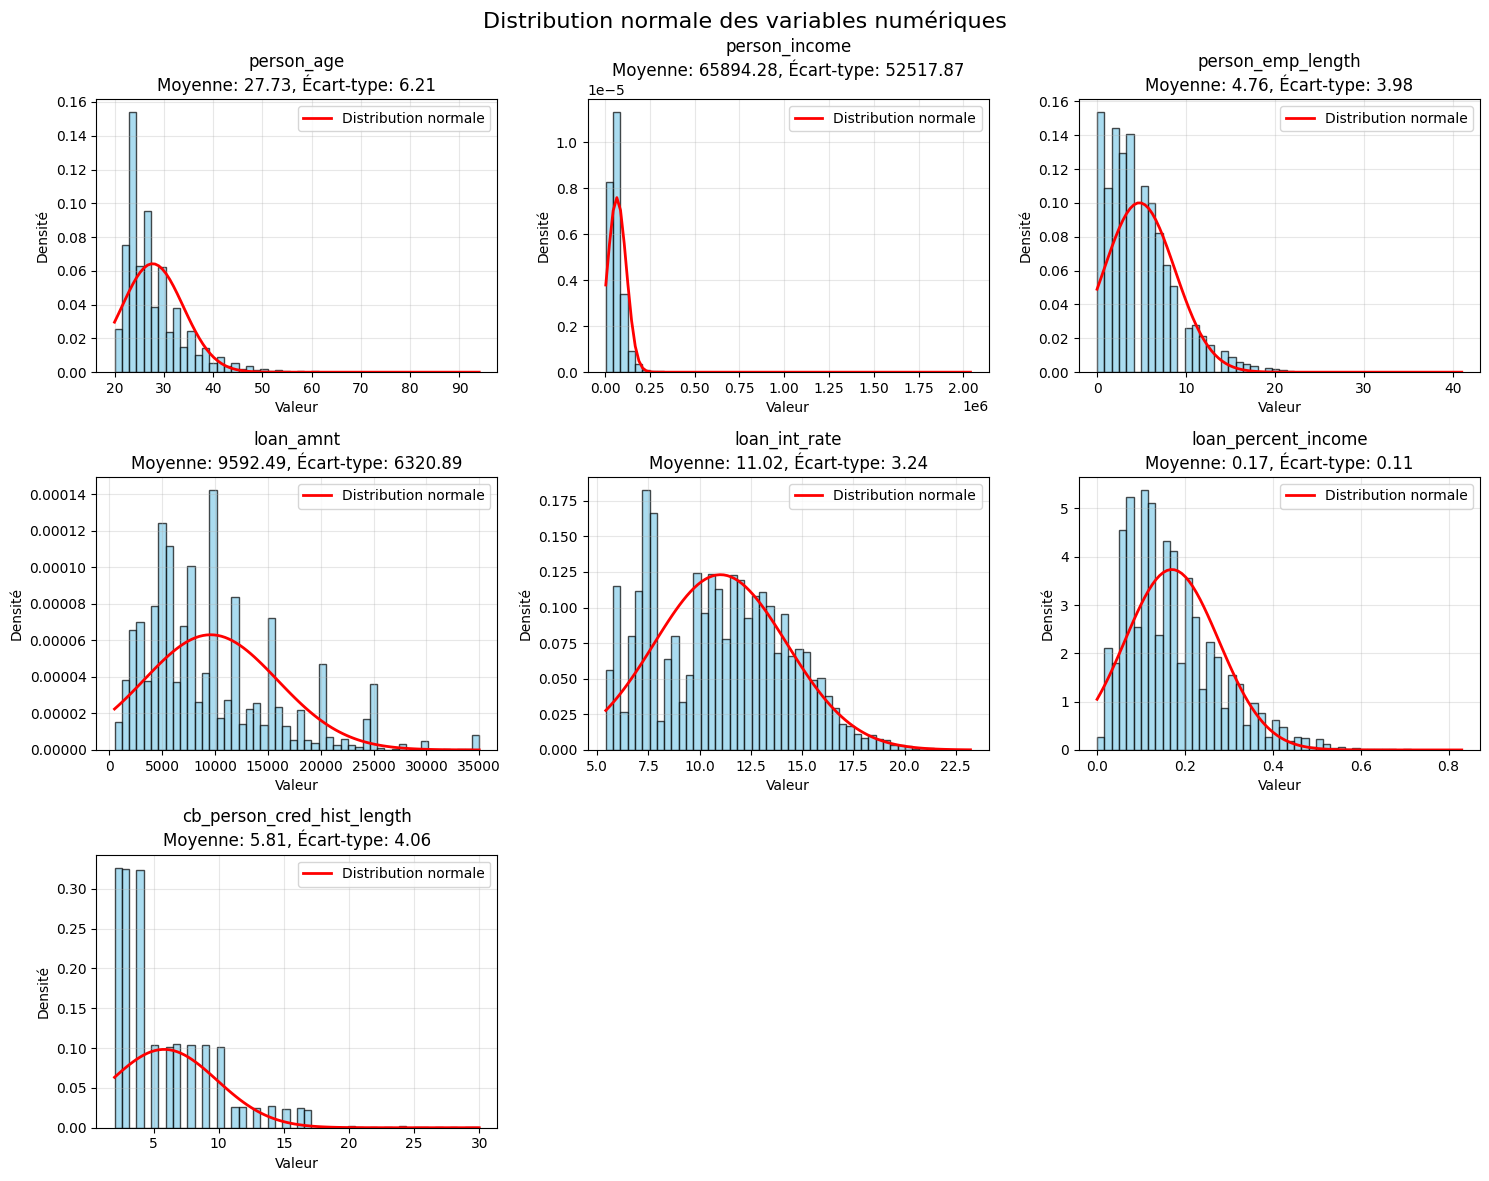

In [33]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Distribution normale des variables numériques', fontsize=16)

axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    data = df[col].dropna()
    
    # Calculer la moyenne et l'écart-type
    mu = data.mean()
    sigma = data.std()
    
    # Créer l'histogramme
    axes[idx].hist(data, bins=50, density=True, alpha=0.7, color='skyblue', edgecolor='black')
    
    x = np.linspace(data.min(), data.max(), 100)
    axes[idx].plot(x, 1/(sigma * np.sqrt(2 * np.pi)) * np.exp(-0.5 * ((x - mu) / sigma) ** 2), 
                   'r-', linewidth=2, label='Distribution normale')
    
    axes[idx].set_title(f'{col}\nMoyenne: {mu:.2f}, Écart-type: {sigma:.2f}')
    axes[idx].set_xlabel('Valeur')
    axes[idx].set_ylabel('Densité')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

for idx in range(len(numeric_cols), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

On observe que certaines variables comme person_age et cb_person_cred_hist_length suivent relativement bien une distribution normale, alors que d'autres comme person_income et loan_amnt présentent des valeurs élevées et une distribution asymétrique. Et Les variables loan_percent_income et person_emp_length montrent également des distributions asymétriques, on pourrait alors les transformer.